# 상권 밀집도 x 택시 빈차시간 공간 분석
- **내부 데이터**: D012 (하차좌표, 빈차시간), H002 (GPS 궤적)
- **외부 데이터**: 소상공인 상가업소 (업종, 좌표)
- **분석 목표**: 상권 밀집도와 택시 빈차시간 관계, 업종별 택시 수요 특성

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'AppleGothic'
# plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

## 1. 데이터 로드

In [4]:
# === 경로 설정 ===
D012_PATH = r"D:\coding-assistant\tmoney\tmoney\DC_TBYXD012.csv"
COMMERCIAL_PATH = r"D:\coding-assistant\tmoney\tmoney\external_data\commercial\seoul_commercial.csv"

# 상가업소 데이터
shops = pd.read_csv(COMMERCIAL_PATH)
shops = shops.dropna(subset=['경도', '위도'])
shops = shops[(shops['경도'] > 126) & (shops['경도'] < 128) & 
              (shops['위도'] > 37) & (shops['위도'] < 38)]

print(f"상가업소 데이터: {len(shops):,}건")
print(f"업종대분류: {shops["업종대분류명"].nunique()}개")
print(shops['업종대분류명'].value_counts().head(10))

상가업소 데이터: 537,489건
업종대분류: 10개
업종대분류명
음식         138558
소매         112810
과학·기술       92306
수리·개인       52039
교육          45080
부동산         24475
시설관리·임대     23812
예술·스포츠      20739
보건의료        18999
숙박           8671
Name: count, dtype: int64


In [5]:
# D012 로드 (좌표, 시간 컬럼)
d012_cols = ['RIDE_DTIME', 'ALIGHT_DTIME', 'PAY_AMT', 'RIDE_DIST',
             'RIDE_POS_X', 'RIDE_POS_Y', 'ALIGHT_POS_X', 'ALIGHT_POS_Y',
             'VACNTV_DIST', 'RIDE_A_CD', 'ALIGHT_A_CD']
d012 = pd.read_csv(D012_PATH, usecols=d012_cols, 
                   dtype={'RIDE_DTIME': str, 'ALIGHT_DTIME': str})

# 좌표 변환 (RIDE_POS_X는 경도, RIDE_POS_Y는 위도*10000000)
d012['ride_lon'] = d012['RIDE_POS_X']
d012['ride_lat'] = d012['RIDE_POS_Y'] / 10000000
d012['alight_lon'] = d012['ALIGHT_POS_X']
d012['alight_lat'] = d012['ALIGHT_POS_Y'] / 10000000

# 서울 범위 필터링
d012 = d012[(d012['ride_lon'] > 126.7) & (d012['ride_lon'] < 127.2) &
            (d012['ride_lat'] > 37.4) & (d012['ride_lat'] < 37.7) &
            (d012['alight_lon'] > 126.7) & (d012['alight_lon'] < 127.2) &
            (d012['alight_lat'] > 37.4) & (d012['alight_lat'] < 37.7)]

# 시간 파싱 & 빈차시간 계산
d012['ride_dt'] = pd.to_datetime(d012['RIDE_DTIME'], format='%Y%m%d%H%M%S', errors='coerce')
d012['alight_dt'] = pd.to_datetime(d012['ALIGHT_DTIME'], format='%Y%m%d%H%M%S', errors='coerce')
d012['hour'] = d012['ride_dt'].dt.hour

print(f"\nD012 (서울 범위): {len(d012):,}행")
print(f"VACNTV_DIST (빈차거리) 평균: {d012['VACNTV_DIST'].mean():,.0f}m")


D012 (서울 범위): 60,000,000행
VACNTV_DIST (빈차거리) 평균: 1,401m


## 2. 그리드 기반 상권 밀집도 산출

In [6]:
# 서울을 500m x 500m 그리드로 분할
# 위도 1도 ≈ 111km, 경도 1도 ≈ 89km (서울 기준)
GRID_SIZE_DEG_LAT = 0.0045   # 약 500m
GRID_SIZE_DEG_LON = 0.0056   # 약 500m

# 상가업소 그리드 배정
shops['grid_lat'] = (shops['위도'] / GRID_SIZE_DEG_LAT).astype(int)
shops['grid_lon'] = (shops['경도'] / GRID_SIZE_DEG_LON).astype(int)
shops['grid_id'] = shops['grid_lat'].astype(str) + '_' + shops['grid_lon'].astype(str)

# 그리드별 상가 수
grid_density = shops.groupby('grid_id').agg(
    shop_count=('상호명', 'count'),
    grid_lat=('grid_lat', 'first'),
    grid_lon=('grid_lon', 'first'),
    center_lat=('위도', 'mean'),
    center_lon=('경도', 'mean')
).reset_index()

# 업종별 그리드 밀집도
grid_category = shops.groupby(['grid_id', '업종대분류명']).size().reset_index(name='count')
grid_top_category = grid_category.sort_values('count', ascending=False).drop_duplicates('grid_id')
grid_density = grid_density.merge(grid_top_category[['grid_id', '업종대분류명']], on='grid_id', how='left')
grid_density.rename(columns={'업종대분류명': 'dominant_category'}, inplace=True)

print(f"그리드 수: {len(grid_density):,}개")
print(f"상가 수 범위: {grid_density['shop_count'].min()} ~ {grid_density['shop_count'].max()}")
print(f"평균: {grid_density['shop_count'].mean():.0f}개/그리드")

# 밀집도 구간 분류
grid_density['density_level'] = pd.qcut(grid_density['shop_count'], q=5, 
                                         labels=['매우낮음', '낮음', '보통', '높음', '매우높음'])
grid_density['density_level'].value_counts()

그리드 수: 2,035개
상가 수 범위: 1 ~ 2741
평균: 264개/그리드


density_level
매우낮음    411
보통      408
높음      407
매우높음    406
낮음      403
Name: count, dtype: int64

In [7]:
# 택시 하차 위치를 같은 그리드에 배정
d012['grid_lat'] = (d012['alight_lat'] / GRID_SIZE_DEG_LAT).astype(int)
d012['grid_lon'] = (d012['alight_lon'] / GRID_SIZE_DEG_LON).astype(int)
d012['grid_id'] = d012['grid_lat'].astype(str) + '_' + d012['grid_lon'].astype(str)

# 택시 승차 위치도 그리드 배정
d012['ride_grid_lat'] = (d012['ride_lat'] / GRID_SIZE_DEG_LAT).astype(int)
d012['ride_grid_lon'] = (d012['ride_lon'] / GRID_SIZE_DEG_LON).astype(int)
d012['ride_grid_id'] = d012['ride_grid_lat'].astype(str) + '_' + d012['ride_grid_lon'].astype(str)

# 그리드별 택시 하차건수 & 빈차거리
taxi_grid = d012.groupby('grid_id').agg(
    alight_count=('PAY_AMT', 'count'),
    avg_vacancy_dist=('VACNTV_DIST', 'mean'),
    avg_fare=('PAY_AMT', 'mean')
).reset_index()

# 상권 밀집도 + 택시 지표 조인
analysis = grid_density.merge(taxi_grid, on='grid_id', how='inner')
print(f"분석 그리드: {len(analysis):,}개 (상가+택시 모두 있는 그리드)")
analysis.head()

분석 그리드: 473개 (상가+택시 모두 있는 그리드)


,grid_id,shop_count,grid_lat,grid_lon,center_lat,center_lon,dominant_category,density_level,alight_count,avg_vacancy_dist,avg_fare
0,8329_22680,558,8329,22680,37.483091,127.011203,과학·기술,매우높음,1,1446.000000,6400.000000
1,8329_22681,570,8329,22681,37.484190,127.017213,소매,매우높음,7,1451.285714,7828.571429
2,8329_22682,246,8329,22682,37.483970,127.021192,과학·기술,높음,47,1549.382979,7000.000000
3,8329_22683,68,8329,22683,37.484487,127.029298,과학·기술,낮음,73,1512.616438,7204.109589
4,8329_22684,354,8329,22684,37.484254,127.033959,음식,높음,53,1409.056604,7058.490566


## 3. 상권 밀집도 vs 빈차거리 관계

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

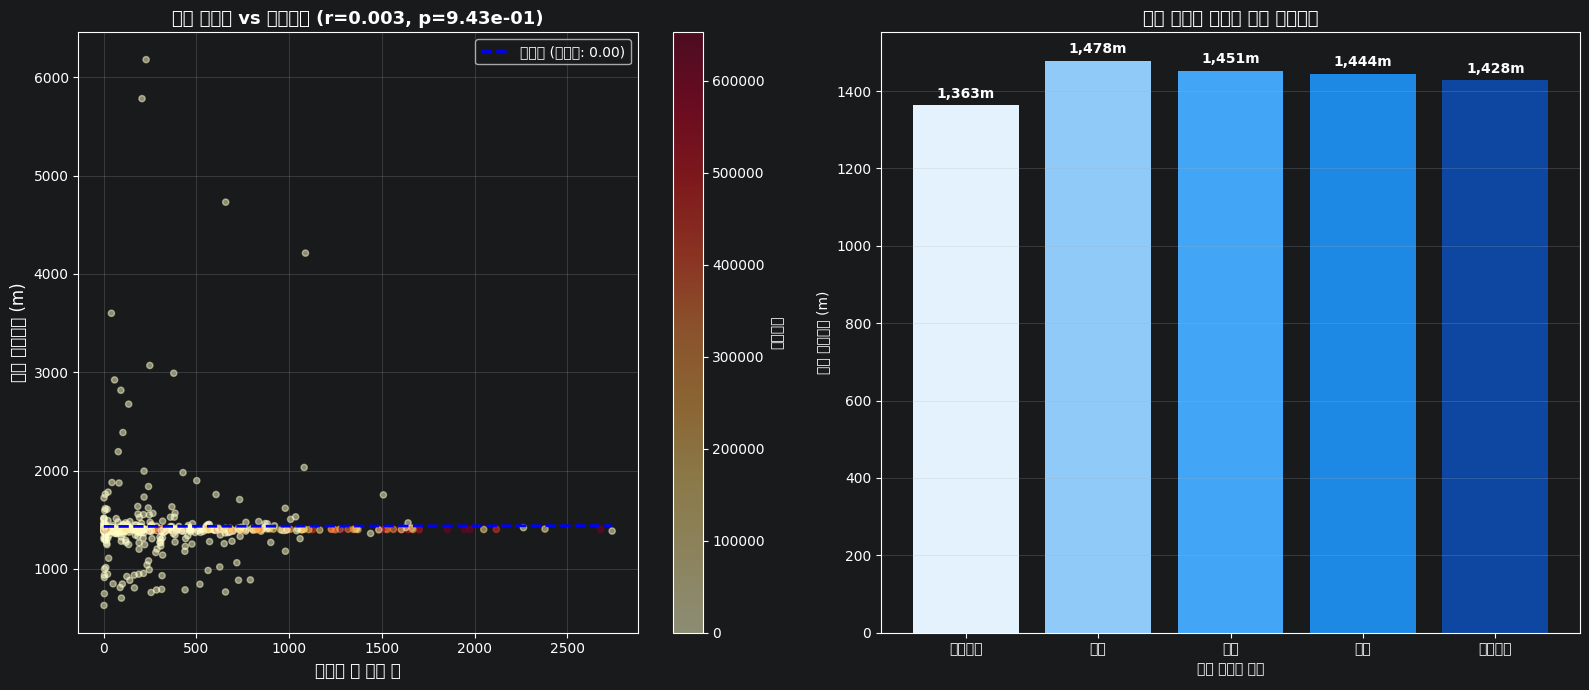


밀집도 구간별 상세:


,density_level,avg_vacancy,avg_fare,avg_alight,grid_count
0,매우낮음,1363.080517,7090.110097,56388.754386,57
1,낮음,1477.885250,7214.130356,31427.846154,52
2,보통,1451.429657,7148.319698,43973.866667,90
3,높음,1444.197516,7064.635822,118502.076190,105
4,매우높음,1427.934759,7137.462106,221048.775148,169


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# 좌: 산점도 (상가 수 vs 빈차거리)
scatter = ax1.scatter(analysis['shop_count'], analysis['avg_vacancy_dist'], 
                       c=analysis['alight_count'], cmap='YlOrRd', 
                       alpha=0.5, s=20, norm=Normalize(vmin=0, vmax=analysis['alight_count'].quantile(0.95)))
plt.colorbar(scatter, ax=ax1, label='하차건수')

# 추세선
z = np.polyfit(analysis['shop_count'], analysis['avg_vacancy_dist'], 1)
p = np.poly1d(z)
x_range = np.linspace(analysis['shop_count'].min(), analysis['shop_count'].max(), 100)
ax1.plot(x_range, p(x_range), color='blue', linewidth=2, linestyle='--', label=f'추세선 (기울기: {z[0]:.2f})')

r, pval = stats.pearsonr(analysis['shop_count'], analysis['avg_vacancy_dist'])
ax1.set_xlabel('그리드 내 상가 수', fontsize=12)
ax1.set_ylabel('평균 빈차거리 (m)', fontsize=12)
ax1.set_title(f'상가 밀집도 vs 빈차거리 (r={r:.3f}, p={pval:.2e})', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 우: 밀집도 구간별 평균 빈차거리
density_stats = analysis.groupby('density_level', observed=True).agg(
    avg_vacancy=('avg_vacancy_dist', 'mean'),
    avg_fare=('avg_fare', 'mean'),
    avg_alight=('alight_count', 'mean'),
    grid_count=('grid_id', 'count')
).reset_index()

colors = ['#E3F2FD', '#90CAF9', '#42A5F5', '#1E88E5', '#0D47A1']
ax2.bar(density_stats['density_level'].astype(str), density_stats['avg_vacancy'], color=colors)
ax2.set_xlabel('상권 밀집도 구간')
ax2.set_ylabel('평균 빈차거리 (m)')
ax2.set_title('상권 밀집도 구간별 평균 빈차거리', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

for i, v in enumerate(density_stats['avg_vacancy']):
    ax2.text(i, v + 20, f'{v:,.0f}m', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n밀집도 구간별 상세:")
density_stats

## 4. 업종별 택시 수요 특성

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

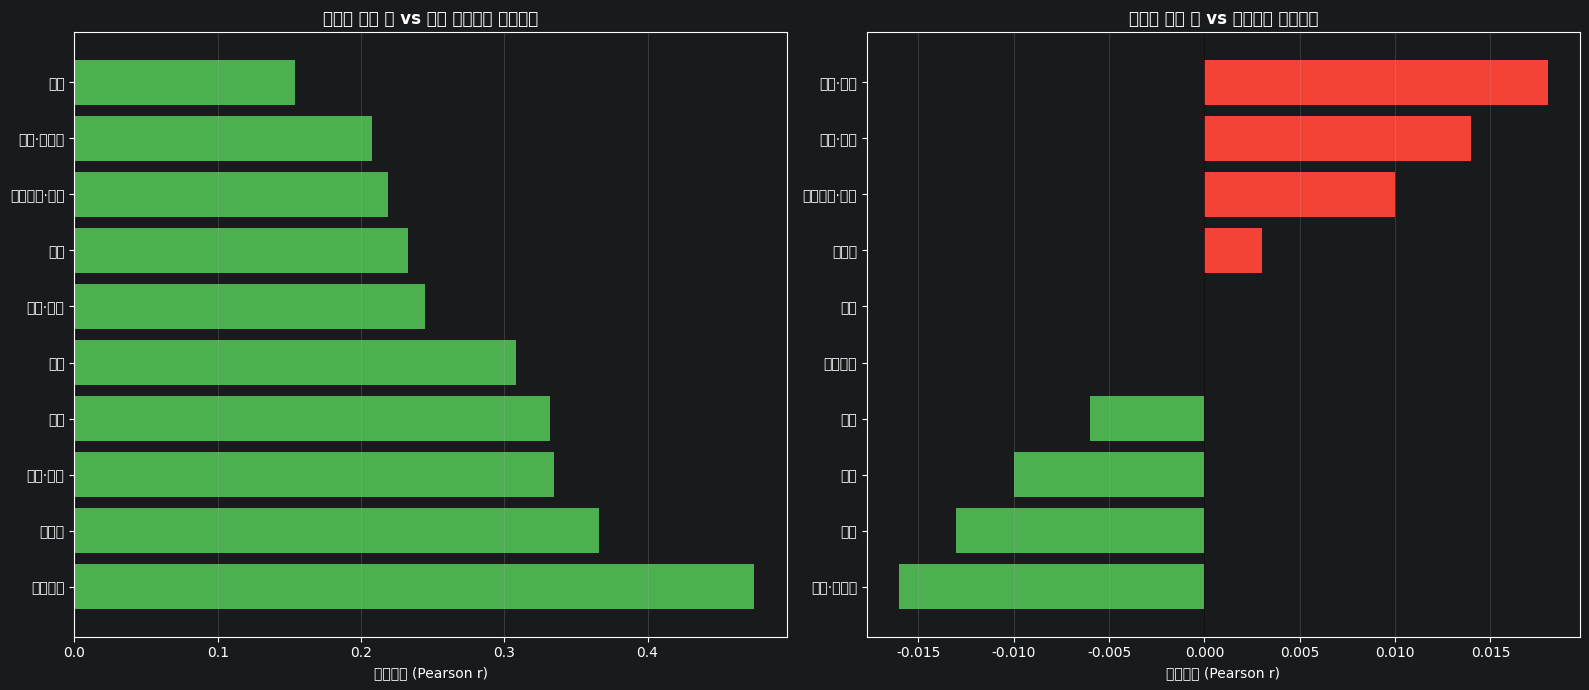


업종별 상관분석 결과:


,업종,하차건수_상관계수,하차건수_p값,빈차거리_상관계수,평균_상가수
2,보건의료,0.474,7.99e-28,0.000,13.8
3,부동산,0.366,1.84e-16,0.003,19.4
0,과학·기술,0.335,7.87e-14,0.018,96.5
1,교육,0.332,1.14e-13,-0.000,33.4
9,음식,0.308,7.41e-12,-0.010,110.2
5,수리·개인,0.245,7.21e-08,0.014,31.4
4,소매,0.233,3.16e-07,-0.006,89.5
7,시설관리·임대,0.219,1.54e-06,0.010,22.1
8,예술·스포츠,0.208,4.98e-06,-0.016,13.1
6,숙박,0.154,7.66e-04,-0.013,9.8


In [9]:
# 업종별 그리드 밀집도와 택시 하차건수 관계
category_cols = shops['업종대분류명'].unique()

# 그리드별 업종별 상가 수
grid_cat_pivot = shops.groupby(['grid_id', '업종대분류명']).size().unstack(fill_value=0)

# 택시 하차건수와 조인
cat_analysis = grid_cat_pivot.merge(taxi_grid[['grid_id', 'alight_count', 'avg_vacancy_dist']], 
                                     on='grid_id', how='inner')

# 업종별 택시 수요 상관계수
correlations = []
for cat in grid_cat_pivot.columns:
    if cat in cat_analysis.columns:
        r, p = stats.pearsonr(cat_analysis[cat], cat_analysis['alight_count'])
        r_v, p_v = stats.pearsonr(cat_analysis[cat], cat_analysis['avg_vacancy_dist'])
        correlations.append({
            '업종': cat,
            '하차건수_상관계수': round(r, 3),
            '하차건수_p값': f'{p:.2e}',
            '빈차거리_상관계수': round(r_v, 3),
            '평균_상가수': round(cat_analysis[cat].mean(), 1)
        })

corr_df = pd.DataFrame(correlations).sort_values('하차건수_상관계수', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# 좌: 업종별 택시 하차건수 상관계수
colors = ['#4CAF50' if v > 0 else '#F44336' for v in corr_df['하차건수_상관계수']]
ax1.barh(corr_df['업종'], corr_df['하차건수_상관계수'], color=colors)
ax1.set_xlabel('상관계수 (Pearson r)')
ax1.set_title('업종별 상가 수 vs 택시 하차건수 상관관계', fontweight='bold')
ax1.axvline(x=0, color='black', linewidth=0.5)
ax1.grid(True, alpha=0.3, axis='x')

# 우: 업종별 빈차거리 상관계수
corr_df_v = corr_df.sort_values('빈차거리_상관계수')
colors_v = ['#4CAF50' if v < 0 else '#F44336' for v in corr_df_v['빈차거리_상관계수']]
ax2.barh(corr_df_v['업종'], corr_df_v['빈차거리_상관계수'], color=colors_v)
ax2.set_xlabel('상관계수 (Pearson r)')
ax2.set_title('업종별 상가 수 vs 빈차거리 상관관계', fontweight='bold')
ax2.axvline(x=0, color='black', linewidth=0.5)
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n업종별 상관분석 결과:")
corr_df

## 5. 상권 유형별 시간대 수요 패턴

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

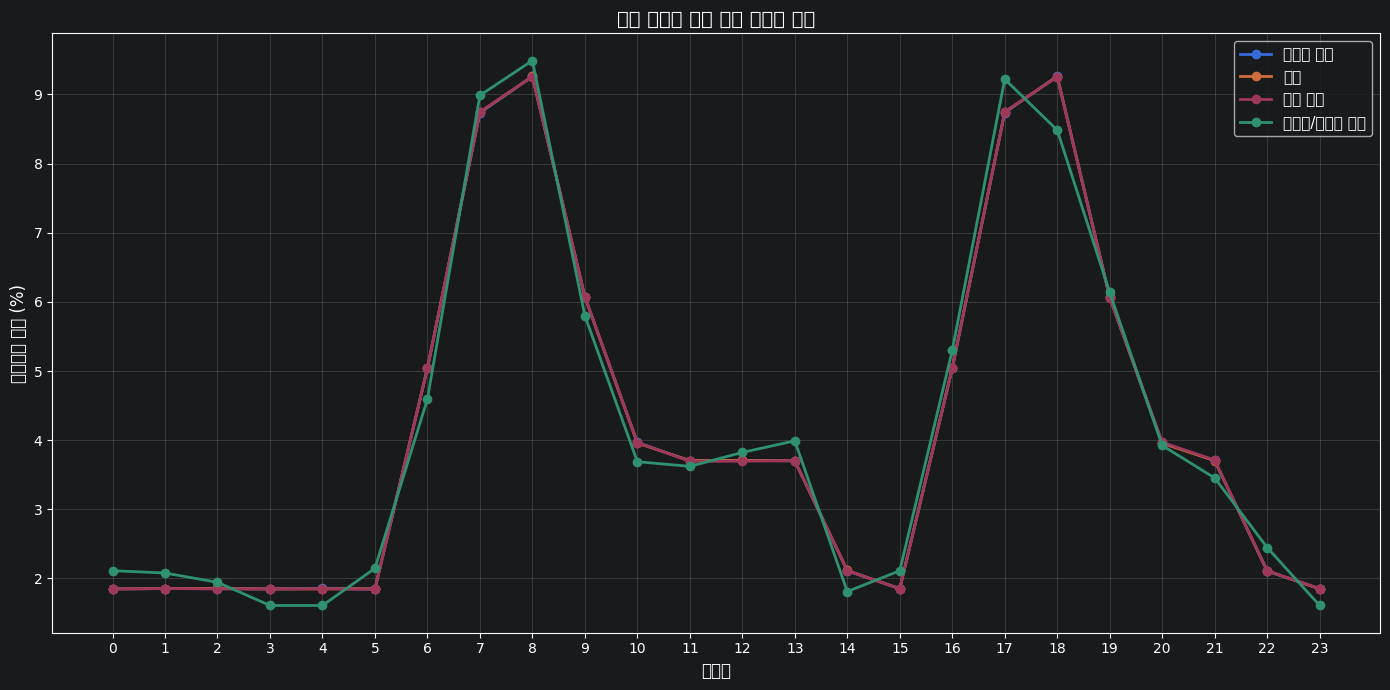

In [10]:
# 주요 업종 밀집 그리드 분류
# dominant_category 기준으로 그리드 유형 분류
type_mapping = {
    '음식': '음식점 밀집',
    '소매': '소매 밀집',
    '생활서비스': '생활서비스 밀집',
    '부동산': '오피스/부동산 밀집',
    '의료': '의료 밀집',
    '숙박': '유흥/숙박 밀집',
    '스포츠': '스포츠/여가',
    '학문/교육': '교육 밀집'
}

analysis['area_type'] = analysis['dominant_category'].map(type_mapping).fillna('기타')

# 그리드 유형을 택시 데이터에 매핑
d012_typed = d012.merge(analysis[['grid_id', 'area_type', 'shop_count', 'density_level']], 
                         on='grid_id', how='inner')

# 상권 유형별 시간대별 하차건수
type_hourly = d012_typed.groupby(['area_type', 'hour']).size().reset_index(name='alight_count')

# 주요 유형만
top_types = d012_typed['area_type'].value_counts().head(5).index.tolist()

fig, ax = plt.subplots(figsize=(14, 7))

for area_type in top_types:
    subset = type_hourly[type_hourly['area_type'] == area_type]
    # 정규화 (시간대별 비중)
    total = subset['alight_count'].sum()
    ax.plot(subset['hour'], subset['alight_count'] / total * 100, 
            marker='o', linewidth=2, label=area_type)

ax.set_xlabel('시간대', fontsize=12)
ax.set_ylabel('시간대별 비중 (%)', fontsize=12)
ax.set_title('상권 유형별 택시 하차 시간대 분포', fontsize=14, fontweight='bold')
ax.set_xticks(range(24))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. 택시 수요 핫스팟 vs 상가 밀집 핫스팟

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

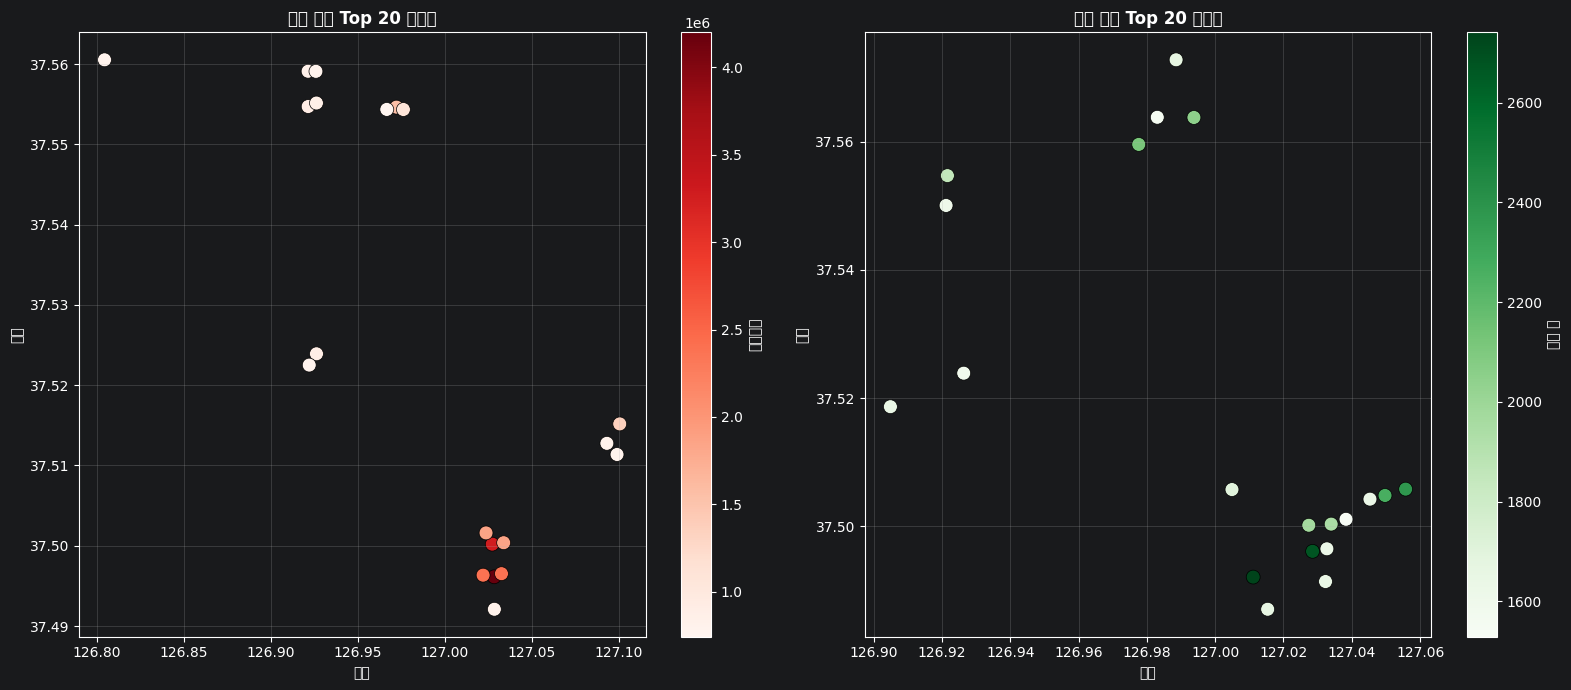


택시 Top 20 ∩ 상가 Top 20 겹치는 그리드: 6개 (30%)

택시 수요 Top 10 그리드:


,grid_id,center_lat,center_lon,shop_count,alight_count,avg_vacancy_dist,dominant_category
37,8332_22683,37.496128,127.028512,2678,4200998,1401.065532,과학·기술
55,8333_22683,37.500196,127.027406,1974,3275971,1401.656528,음식
38,8332_22684,37.496519,127.032707,1624,2387550,1401.744553,과학·기술
36,8332_22682,37.496334,127.022149,640,2385749,1400.793876,과학·기술
56,8333_22684,37.500373,127.033950,1945,1862672,1401.930737,과학·기술
54,8333_22682,37.501594,127.023839,563,1861976,1400.705606,과학·기술
328,8345_22673,37.554634,126.972346,333,1562994,1400.702641,소매
161,8336_22696,37.515174,127.100681,362,1350055,1401.201354,음식
329,8345_22674,37.554340,126.976344,246,1069650,1399.670602,음식
319,8345_22664,37.554709,126.921629,1853,908191,1401.672504,음식


In [11]:
# 상위 20개 그리드 비교 (택시 하차 기준 vs 상가 수 기준)
top_taxi = analysis.nlargest(20, 'alight_count')[['grid_id', 'center_lat', 'center_lon', 
                                                    'shop_count', 'alight_count', 'avg_vacancy_dist',
                                                    'dominant_category']]
top_shop = analysis.nlargest(20, 'shop_count')[['grid_id', 'center_lat', 'center_lon',
                                                  'shop_count', 'alight_count', 'avg_vacancy_dist',
                                                  'dominant_category']]

# 겹치는 그리드
overlap = set(top_taxi['grid_id']) & set(top_shop['grid_id'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# 좌: 택시 수요 Top 20 그리드 위치
scatter1 = ax1.scatter(top_taxi['center_lon'], top_taxi['center_lat'], 
                        c=top_taxi['alight_count'], cmap='Reds', s=100, edgecolors='black', linewidth=0.5)
plt.colorbar(scatter1, ax=ax1, label='하차건수')
ax1.set_xlabel('경도')
ax1.set_ylabel('위도')
ax1.set_title('택시 하차 Top 20 그리드', fontweight='bold')
ax1.grid(True, alpha=0.3)

# 우: 상가 밀집 Top 20 그리드 위치
scatter2 = ax2.scatter(top_shop['center_lon'], top_shop['center_lat'],
                        c=top_shop['shop_count'], cmap='Greens', s=100, edgecolors='black', linewidth=0.5)
plt.colorbar(scatter2, ax=ax2, label='상가 수')
ax2.set_xlabel('경도')
ax2.set_ylabel('위도')
ax2.set_title('상가 밀집 Top 20 그리드', fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n택시 Top 20 ∩ 상가 Top 20 겹치는 그리드: {len(overlap)}개 ({len(overlap)/20*100:.0f}%)")

print("\n택시 수요 Top 10 그리드:")
top_taxi.head(10)

## 7. 행정동별 상가 밀집도 x 택시 수요 관계

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

행정동 수 (상가): 426개
행정동 수 (택시): 20개


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

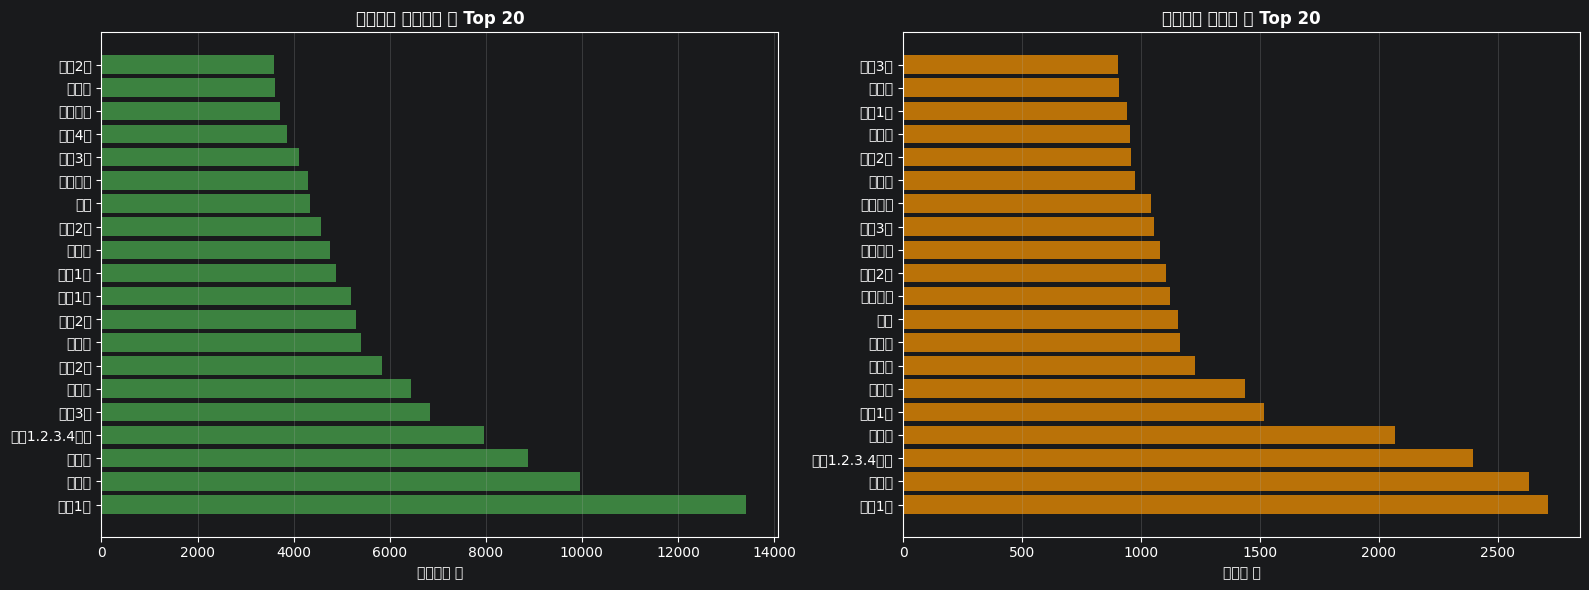

In [12]:
# 행정동별 집계
dong_shops = shops.groupby('행정동명').agg(
    shop_count=('상호명', 'count'),
    restaurant_count=('업종대분류명', lambda x: (x == '음식').sum()),
    retail_count=('업종대분류명', lambda x: (x == '소매').sum()),
    center_lat=('위도', 'mean'),
    center_lon=('경도', 'mean')
).reset_index()

# D012에서 행정동코드별 승차건수 (RIDE_A_CD)
taxi_by_dong = d012.groupby('RIDE_A_CD').agg(
    ride_count=('PAY_AMT', 'count'),
    avg_fare=('PAY_AMT', 'mean'),
    avg_vacancy=('VACNTV_DIST', 'mean')
).reset_index()

print(f"행정동 수 (상가): {len(dong_shops)}개")
print(f"행정동 수 (택시): {taxi_by_dong['RIDE_A_CD'].nunique()}개")

# 시각화: 행정동별 상가 수 분포
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

dong_shops_sorted = dong_shops.nlargest(20, 'shop_count')
ax1.barh(dong_shops_sorted['행정동명'], dong_shops_sorted['shop_count'], color='#4CAF50', alpha=0.7)
ax1.set_xlabel('상가업소 수')
ax1.set_title('행정동별 상가업소 수 Top 20', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

dong_shops_sorted2 = dong_shops.nlargest(20, 'restaurant_count')
ax2.barh(dong_shops_sorted2['행정동명'], dong_shops_sorted2['restaurant_count'], color='#FF9800', alpha=0.7)
ax2.set_xlabel('음식점 수')
ax2.set_title('행정동별 음식점 수 Top 20', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 8. 요약

In [13]:
print("=" * 70)
print("상권 밀집도 x 택시 빈차시간 분석 요약")
print("=" * 70)

# 핵심 지표
r_vacancy, p_vacancy = stats.pearsonr(analysis['shop_count'], analysis['avg_vacancy_dist'])
r_demand, p_demand = stats.pearsonr(analysis['shop_count'], analysis['alight_count'])

print(f"\n1. 분석 그리드 수: {len(analysis):,}개 (500m x 500m)")
print(f"2. 상가 수 vs 택시 하차건수 상관계수: r={r_demand:.3f} (p={p_demand:.2e})")
print(f"3. 상가 수 vs 빈차거리 상관계수: r={r_vacancy:.3f} (p={p_vacancy:.2e})")

# 밀집도별 빈차거리 차이
low = analysis[analysis['density_level'] == '매우낮음']['avg_vacancy_dist'].mean()
high = analysis[analysis['density_level'] == '매우높음']['avg_vacancy_dist'].mean()
print(f"\n4. 상권 밀집도 '매우낮음' 빈차거리: {low:,.0f}m")
print(f"5. 상권 밀집도 '매우높음' 빈차거리: {high:,.0f}m")
print(f"   → 차이: {low - high:,.0f}m ({((low-high)/low)*100:.1f}% 감소)")

# Top 업종
print(f"\n6. 택시 수요와 가장 상관 높은 업종:")
for _, row in corr_df.head(3).iterrows():
    print(f"   - {row['업종']}: r={row['하차건수_상관계수']:.3f}")

print(f"\n7. 택시 Top 20 ∩ 상가 Top 20 핫스팟 일치율: {len(overlap)/20*100:.0f}%")

상권 밀집도 x 택시 빈차시간 분석 요약

1. 분석 그리드 수: 473개 (500m x 500m)
2. 상가 수 vs 택시 하차건수 상관계수: r=0.392 (p=7.99e-19)
3. 상가 수 vs 빈차거리 상관계수: r=0.003 (p=9.43e-01)

4. 상권 밀집도 '매우낮음' 빈차거리: 1,363m
5. 상권 밀집도 '매우높음' 빈차거리: 1,428m
   → 차이: -65m (-4.8% 감소)

6. 택시 수요와 가장 상관 높은 업종:
   - 보건의료: r=0.474
   - 부동산: r=0.366
   - 과학·기술: r=0.335

7. 택시 Top 20 ∩ 상가 Top 20 핫스팟 일치율: 30%
